<center>

## Term Project: Analysing Trends in Movie Performance and Ratings
### Karthika Vellingiri
### 15 Nov 2024
</center>

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import ast
import re
from fuzzywuzzy import fuzz
import langcodes  # Import the langcodes library to handle language codes
import warnings
from IPython.display import display, HTML

# Suppress warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, message="Using slow pure-python SequenceMatcher")

# Step #1: Load the dataset
df = pd.read_csv("../data/movies_metadata.csv", low_memory=False)  # Load the movie metadata CSV file
print(f"Data file 'movies_metadata.csv' loaded successfully.\n")

print("Starting Data cleanup...")  # Indicate that data cleanup is starting

# Step #2: Drop specified columns that are not needed for analysis
columns_to_drop = ['adult', 'belongs_to_collection', 'homepage', 'overview', 'poster_path', 'tagline', 'video']
df = df.drop(columns=columns_to_drop, errors='ignore')  # Drop columns, ignore errors if columns are missing

# Step #3: Remove duplicate rows from the dataset
initial_row_count = df.shape[0]  # Store initial row count for reference
df = df.drop_duplicates()  # Remove duplicate entries

# Step #4: Remove rows with specific criteria that do not meet quality standards
df = df[
    (df['genres'].apply(lambda x: bool(ast.literal_eval(x)) if pd.notnull(x) else False)) &  # Check if genres are valid
    (df['production_companies'].apply(lambda x: bool(ast.literal_eval(x)) if pd.notnull(x) else False)) &  # Check production companies
    (df['production_countries'].apply(lambda x: bool(ast.literal_eval(x)) if pd.notnull(x) else False)) &  # Check production countries
    (df['spoken_languages'].apply(lambda x: bool(ast.literal_eval(x)) if pd.notnull(x) else False)) &  # Check spoken languages
    (df['imdb_id'].notna()) &  # Ensure IMDb ID is present
    (df['imdb_id'] != '') &  # Ensure IMDb ID is not empty
    (df['original_language'].notna()) &  # Ensure original language is present
    (df['original_language'] != '') &  # Ensure original language is not empty
    (df['revenue'].notna()) &  # Ensure revenue is present
    (df['revenue'] != 0) &  # Ensure revenue is greater than zero
    (df['popularity'] != 0)  # Ensure popularity is greater than zero
]

# Step #5: Filter 'original_title' and 'title' to remove entries with invalid characters

#regex pattern for allowed characters
title_character_filter = r"[^0-9!\"#%&'()*+,\-./:;<=>?@\[\\\]^_`{|}~\sA-Za-z]"

df = df[~(
    df['original_title'].str.contains(title_character_filter, regex=True) |
    df['title'].str.contains(title_character_filter, regex=True)
)]


# Step #6: Validate 'production_companies' for proper names and IDs
df = df[df['production_companies'].apply(lambda x: all(
    isinstance(company.get('name', ''), str) and company.get('name') and isinstance(company.get('id', 0), int)
    for company in ast.literal_eval(x)) if pd.notnull(x) else False)]  # Ensure each company has a valid name and ID

# Step #7: Validate 'production_countries' for proper ISO codes and names
df = df[df['production_countries'].apply(lambda x: all(
    isinstance(country.get('iso_3166_1', ''), str) and len(country.get('iso_3166_1')) == 2 and
    isinstance(country.get('name', ''), str) and country.get('name')
    for country in ast.literal_eval(x)) if pd.notnull(x) else False)]  # Ensure each country has valid ISO codes and names

# Step #8: Remove rows with inappropriate revenue values (less than 10,000)
df = df[df['revenue'] > 10000]  # Filter out low-revenue entries

# Step #9: Remove rows with inappropriate budget values (less than 50,000)
df['budget'] = pd.to_numeric(df['budget'], errors='coerce')  # Convert budget to numeric, coerce errors to NaN
df = df[df['budget'] > 50000]  # Filter out low-budget entries

# Step #10: Handle 'runtime' column for missing values
avg_runtime = 90  # Define average runtime to use for filtering
df['runtime'] = df['runtime'].apply(lambda x: avg_runtime if pd.isnull(x) else x)  # Fill missing runtime with average value

# Remove rows with runtime less than 90 minutes and greater than 180 minutes
df = df[(df['runtime'] >= 90) & (df['runtime'] <= 180)]  # Filter for valid runtime entries

# Step #11: Derive 'genres' from the dataset
def derive_genres(genres):
    """Extracts genre names from the JSON-like structure in the 'genres' column."""
    if pd.isnull(genres):  # Check for null values
        return ""
    try:
        genre_list = ast.literal_eval(genres)  # Convert string to list
        return ", ".join([genre['name'] for genre in genre_list])  # Return a comma-separated string of genre names
    except (ValueError, SyntaxError):  # Handle potential parsing errors
        return ""

df['genres'] = df['genres'].apply(derive_genres)  # Apply the genre extraction function

# Step #12: Create multigenre column to indicate if multiple genres are present
def check_multigenre(genres):
    """Check if a movie has multiple genres."""
    if pd.isnull(genres) or genres == "":  # Check for null or empty genres
        return "no"  # Return "no" if no genres are present
    genre_list = [genre.strip() for genre in genres.split(",")]  # Split genres into a list
    return "yes" if len(genre_list) > 1 else "no"  # Return "yes" if multiple genres exist

df['multigenre'] = df['genres'].apply(check_multigenre)  # Apply the multigenre check

# Step #13: Process spoken languages to create multilanguage column
def process_spoken_languages(languages):
    """Convert spoken languages data into a comma-separated string and check if multiple languages exist."""
    if pd.isnull(languages):  # Check for null languages
        return "", "no"  # Return empty string and "no"
    
    language_list = [language['iso_639_1'] for language in ast.literal_eval(languages)]  # Extract ISO language codes
    
    # Use langcodes to map language codes to names
    mapped_languages = [langcodes.Language.get(lang_code).language_name() for lang_code in language_list]
    
    # Filter out any that didn't map successfully
    cleaned_languages = [lang for lang in mapped_languages if lang]  # Keep only successfully mapped languages
    
    multilanguage = "yes" if len(cleaned_languages) > 1 else "no"  # Check if there are multiple languages
    return ", ".join(cleaned_languages), multilanguage  # Return cleaned languages and multilanguage indicator

# Apply the process_spoken_languages function to the spoken_languages column
df[['spoken_languages', 'multilanguage']] = df['spoken_languages'].apply(lambda x: pd.Series(process_spoken_languages(x)))

# Step #14: Process production companies to create multicompany column
def process_production_companies(companies):
    """Convert production companies data into a comma-separated string and check if multiple companies exist."""
    if pd.isnull(companies):  # Check for null companies
        return "", "no"  # Return empty string and "no"
    
    company_list = [company['name'] for company in ast.literal_eval(companies)]  # Extract company names
    multicompany = "yes" if len(company_list) > 1 else "no"  # Check if there are multiple companies
    return ", ".join(company_list), multicompany  # Return company names and multicompany indicator

# Apply the process_production_companies function to the production_companies column
df[['production_companies', 'multicompany']] = df['production_companies'].apply(lambda x: pd.Series(process_production_companies(x)))

# Step #15: Process production countries to create multicountry column
def process_production_countries(countries):
    """Convert production countries data into a comma-separated string and check if multiple countries exist."""
    if pd.isnull(countries):  # Check for null countries
        return "", "no"  # Return empty string and "no"
    
    country_list = [country['name'] for country in ast.literal_eval(countries)]  # Extract country names
    multicountry = "yes" if len(country_list) > 1 else "no"  # Check if there are multiple countries
    return ", ".join(country_list), multicountry  # Return country names and multicountry indicator

# Apply the process_production_countries function to the production_countries column
df[['production_countries', 'multicountry']] = df['production_countries'].apply(lambda x: pd.Series(process_production_countries(x)))

# Step #16: Fuzzy match 'original_title' and 'title' to ensure they are similar
df = df[df.apply(lambda row: fuzz.ratio(row['original_title'], row['title']) > 80, axis=1)]  # Keep only rows with high similarity

# Step #17: Filter 'status' column for only "Released" status
df = df[df['status'] == 'Released']  # Retain only movies that have been released

# Step #18: Filter 'vote_average' and 'vote_count' columns for appropriate values
df = df[~((df['vote_average'] < 5.0) & (df['vote_count'] < 100))]  # Exclude low-rated and low-vote movies

# Step #19: Validate Data Types
def validate_data_types(df):
    """Check if numeric columns are indeed numeric and categorical columns are strings."""
    expected_types = {
        'budget': 'numeric',
        'revenue': 'numeric',
        'runtime': 'numeric',
        'vote_average': 'numeric',
        'vote_count': 'numeric',
        'original_language': 'string',
        'status': 'string',
        'imdb_id': 'string'
    }
    
    for column, expected_type in expected_types.items():
        if expected_type == 'numeric' and not pd.api.types.is_numeric_dtype(df[column]):
            print(f"Warning: {column} is not numeric!")  # Alert if column is not numeric
        elif expected_type == 'string' and not pd.api.types.is_string_dtype(df[column]):
            print(f"Warning: {column} is not a string!")  # Alert if column is not string

validate_data_types(df)  # Validate the data types of the DataFrame

# Step #20: Convert 'popularity' to numeric, forcing errors to NaN
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')  # Convert popularity to numeric

# Step #21: Round off popularity to 2 decimal points
df['popularity'] = df['popularity'].round(2)  # Round popularity to 2 decimal points

# Step #22: Format revenue and budget in dollars
df['revenue'] = df['revenue'].apply(lambda x: f"${x:,.2f}")  # Format revenue with dollar sign and commas
df['budget'] = df['budget'].apply(lambda x: f"${x:,.2f}")  # Format budget with dollar sign and commas

# Step #23: Remove decimal from vote count
df['vote_count'] = df['vote_count'].astype(int)  # Convert vote count to integer to remove decimals

# Step #24: Convert column names to lowercase for consistency
df.columns = [col.lower() for col in df.columns]  # Change all column names to lowercase

# Indicate the completion of data cleanup
print("Data cleanup completed successfully!!!")  # Notify that the cleanup process has finished

# Step #25: Rename runtime column and remove decimal
df.rename(columns={'runtime': 'runtime(in_minutes)'}, inplace=True)  # Rename runtime column
df['runtime(in_minutes)'] = df['runtime(in_minutes)'].astype(int)  # Convert to integer to remove decimals

# Step #26: Print dataset before and after cleanup for comparison
display(HTML("<br><center><h3><strong>Dataset before cleanup</h3></strong></center>"))

initial_df = pd.read_csv("movies_metadata.csv", low_memory=False)  # Load the original dataset again for comparison
display(HTML(initial_df.head().to_html(index=False)))  # Display the first few rows of the original dataset

display(HTML("<br><center><strong><h3>Dataset after cleanup</h3></strong></center>"))
display(HTML(df.head().to_html(index=False)))  # Display the first few rows of the cleaned dataset

# Save the cleaned dataset to a new CSV file
cleaned_file = "../appendix/cleaned_movies_metadata.csv"  # Define the output file path
df.to_csv(cleaned_file, index=False)  # Save the cleaned DataFrame to CSV
print(f"Cleaned dataset saved to {cleaned_file}.\n")  # Notify that the cleaned dataset has been saved

file_dataset = df
# display(HTML(file_dataset.head().to_html(index=False)))  # Display the first few rows of the cleaned dataset.

Data file 'movies_metadata.csv' loaded successfully.

Starting Data cleanup...
Data cleanup completed successfully!!!


adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
False,"{'id': 10194, 'name': 'Toy Story Collection', 'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg', 'backdrop_path': '/9FBwqcd9IRruEDUrTdcaafOMKUq.jpg'}",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences.",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, 'name': 'Fantasy'}, {'id': 10751, 'name': 'Family'}]",NaN,8844,tt0113497,en,Jumanji,"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwittingly invite Alan -- an adult who's been trapped inside the game for 26 years -- into their living room. Alan's only hope for freedom is to finish the game, which proves risky as all three find themselves running from giant rhinoceroses, evil monkeys and other terrifying creatures.",17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'name': 'Teitler Film', 'id': 2550}, {'name': 'Interscope Communications', 'id': 10201}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso_639_1': 'fr', 'name': 'Français'}]",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
False,"{'id': 119050, 'name': 'Grumpy Old Men Collection', 'poster_path': '/nLvUdqgPgm3F85NMCii9gVFUcet.jpg', 'backdrop_path': '/hypTnLot2z8wpFS7qwsQHW1uV8u.jpg'}",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, 'name': 'Comedy'}]",NaN,15602,tt0113228,en,Grumpier Old Men,"A family wedding reignites the ancient feud between next-door neighbors and fishing buddies John and Max. Meanwhile, a sultry Italian divorcée opens a restaurant at the local bait shop, alarming the locals who worry she'll scare the fish away. But she's less interested in seafood than she is in cooking up a hot time with Max.",11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name': 'Lancaster Gate', 'id': 19464}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for Love.,Grumpier Old Men,False,6.5,92.0
False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'name': 'Drama'}, {'id': 10749, 'name': 'Romance'}]",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the women are holding their breath, waiting for the elusive ""good man"" to break a string of less-than-stellar lovers. Friends and confidants Vannah, Bernie, Glo and Robin talk it all out, determined to find a better way to breathe.",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,"[{'name': 'Twentieth Century Fox Film Corporation', 'id': 306}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself... and never let you forget it.,Waiting to Exhale,False,6.1,34.0
False,"{'id': 96871, 'name': 'Father of the Bride Collection', 'poster_path': '/nts4iOmNnq7GNicycMJ9pSAn204.jpg', 'backdrop

budget,genres,id,imdb_id,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime(in_minutes),spoken_languages,status,title,vote_average,vote_count,multigenre,multilanguage,multicompany,multicountry
"$65,000,000.00","Adventure, Fantasy, Family",8844,tt0113497,en,Jumanji,17.02,"TriStar Pictures, Teitler Film, Interscope Communications",United States of America,1995-12-15,"$262,797,249.00",104,"English, French",Released,Jumanji,6.9,2413,yes,yes,yes,no
"$16,000,000.00","Comedy, Drama, Romance",31357,tt0114885,en,Waiting to Exhale,3.86,Twentieth Century Fox Film Corporation,United States of America,1995-12-22,"$81,452,156.00",127,English,Released,Waiting to Exhale,6.1,34,yes,no,no,no
"$60,000,000.00","Action, Crime, Drama, Thriller",949,tt0113277,en,Heat,17.92,"Regency Enterprises, Forward Pass, Warner Bros.",United States of America,1995-12-15,"$187,436,818.00",170,"English, Spanish",Released,Heat,7.7,1886,yes,yes,yes,no
"$35,000,000.00","Action, Adventure, Thriller",9091,tt0114576,en,Sudden Death,5.23,"Universal Pictures, Imperial Entertainment, Signature Entertainment",United States of America,1995-12-22,"$64,350,171.00",106,English,Released,Sudden Death,5.5,174,yes,no,yes,no
"$58,000,000.00","Adventure, Action, Thriller",710,tt0113189,en,GoldenEye,14.69,"United Artists, Eon Productions","United Kingdom, United States of America",1995-11-16,"$352,194,034.00",130,"English, Russian, Spanish",Released,GoldenEye,6.6,1194,yes,yes,yes,yes


Cleaned dataset saved to cleaned_movies_metadata.csv.




### Importing Libraries and Setting Up
- **Imports necessary libraries**: Handles data manipulation (`pandas`, `numpy`), parsing JSON-like structures (`ast`), and fuzzy matching for text similarity (`fuzzywuzzy`). It also imports `langcodes` for handling language codes and `warnings` to suppress specific warnings.
- **Suppresses deprecation warnings** to keep the output clean.

### Loading the Dataset
1. **Load the data**: Reads `movies_metadata.csv` into a DataFrame named `df`.
2. **Start data cleanup**: Prints a message indicating the start of data cleaning.

### Data Cleanup Steps
#### Step 1-3: Dropping Unneeded Columns and Duplicate Rows
- **Drops columns**: Removes specified columns (`adult`, `belongs_to_collection`, etc.) to retain only necessary data.
- **Removes duplicate rows**: Removes duplicate entries to ensure unique records.

#### Step 4: Filtering Data Based on Specific Conditions
This step filters rows to remove invalid or incomplete data based on specific criteria, including:
- Valid genres, production companies, production countries, and spoken languages.
- Non-empty IMDb IDs and original languages.
- Non-zero values for revenue#### Step 5-6: Cleaning Titles and Production Companies
- **Filters out titles with invalid characters**: Uses a regular expression to remove entries in the `original_title` and `title` columns that contain characters outside the allowed range (letters, spaces, and common punctuation marks).
- **Validates production companies**: Ensures each company in the `production_companies` column has a valid `name` (non-empty string) and `id` (integer).any has a name and ID.

#### Step 7-9: Validating Production Countries and Budget/Revenue Values
- **Validates production countries**: Checks for valid ISO codes and country names.
- **Filters out low revenue and budget**: Removes rows with revenue less than $10,000 and budget less than $50,000.

#### Step 10: Handling Missing Runtime Values
- **Fills missing runtime values**: Fills missing values with an average runtime of 90 minutes.
- **Filters based on runtime**: Keeps rows where runtime is between 90 and 180 minutes.

#### Step 11-12: Extracting Genres and Checking for Multiple Genres
- **Extracts genres**: Converts the JSON-like genre structure into a comma-separated string of genre names.
- **Adds a 'multigenre' column**: Indicates if a movie has multiple genres.

#### Step 13-15: Processing Languages, Production Companies, and Production Countries
Each of these steps converts JSON-like structures to readable strings and creates columns to indicate if multiple entities exist:
- **Processes spoken languages**: Maps ISO language codes to language names and checks for multiple languages.
- **Processes production companies and countries**: Extracts names and checks if multiple companies or countries are involved.

#### Step 16-18: Filtering Based on Title Similarity, Status, and Vote Count/Average
- **Fuzzy matches titles**: Ensures `original_title` and `title` have at least 80% similarity.
- **Keeps only "Released" movies**.
- **Filters by vote count and average**: Excludes movies with a low rating and few votes.

#### Step 19: Validating Data Types
- **Validates data types**: Checks if numeric columns are indeed numeric and categorical columns are strings, issuing warnings if they are not.

#### Step 20-26: Final Cleanup and Formatting
- **Converts 'popularity' to numeric** and rounds to two decimal points.
- **Formats 'revenue' and 'budget'** as dollar values with commas.
- **Removes decimals from 'vote_count'** by converting it to integer.
- **Standardizes column names to lowercase**.
- **Renames and removes decimal from 'runtime' column** for consistency.

### Displaying Before and After Datasets
- **Loads the original dataset** to display the initial rows, then displays the cleaned dataset for comparison.

### Saving the Cleaned Dataset
- **Saves the cleaned dataset** to a new CSV file (`cleaned_movies_metadata.csv`) and confirms the save.

This cleanup workflow prepares the dataset for analysis by removing irrelevant or incomplete data, ensuring consistency, and structuring columns in a readable and analyzable format.

In [6]:
from bs4 import BeautifulSoup  # Import BeautifulSoup for HTML parsing
import pandas as pd  # Import pandas for data manipulation
import requests  # Import requests to make HTTP requests
from IPython.display import display, HTML  # Import display functions for HTML output

# Function to extract data for a given year
def extract_data(year):
    url = f"https://www.boxofficemojo.com/year/world/{year}/"  # Construct URL with the year
    response = requests.get(url)  # Send a request to the URL
    soup = BeautifulSoup(response.text, "html.parser")  # Parse the HTML content
    
    # Find the table with movie data on the page
    table = soup.find("table")
    if table is None:  # If no table is found, return an empty DataFrame
        return pd.DataFrame()
    
    rows = table.find_all("tr")  # Find all rows in the table
    
    # Extract column headers from the first row (header row)
    headers = [header.text.strip() for header in rows[0].find_all("th")]
    
    # Extract data from each row after the header row
    data = []
    for row in rows[1:]:
        cols = row.find_all("td")  # Find all columns in each row
        cols = [col.text.strip() for col in cols]  # Strip whitespace from each cell
        data.append(cols)  # Append row data to the data list
    
    # Create a DataFrame from the extracted data and add 'Year' column
    df = pd.DataFrame(data, columns=headers)
    df['Year'] = year  # Add the year to the DataFrame
    return df  # Return the DataFrame for the year

# Step 1: Loop through years and extract data
print("Starting Data Extraction . . .")  # Initial message
all_data = []  # Initialize list to store all years' data
for i, year in enumerate(range(1977, 2021), start=1):  # Loop through years 1977 to 2020
    year_data = extract_data(year)  # Call function to extract data for the year
    all_data.append(year_data)  # Append the DataFrame to all_data
    if year != 2020:
        print(f"Data Extraction completed for the year {year}...", end='\r')  # Print message for each year, replacing in-place
    else:
        print("Data Extraction completed Successfully ! ! ! ", flush=True)  # Print completion message for the last year

# Step 2: Combine all data into a single DataFrame
combined_df = pd.concat(all_data, ignore_index=True)  # Concatenate all DataFrames into one large DataFrame
# Copy combined_df to original_df, excluding the 'Year' column to have the exact table content
original_df = combined_df.drop(columns=['Year']).copy()  # Drop 'Year' and create a copy for comparison

# Step 3: Sort combined DataFrame by 'Worldwide' before cleaning
combined_df['Worldwide'] = combined_df['Worldwide'].replace({'\$': '', ',': ''}, regex=True).astype(float)  # Remove dollar signs and commas, convert to float for sorting
combined_df = combined_df.sort_values(by='Worldwide', ascending=False).reset_index(drop=True)  # Sort by Worldwide revenue

# Step 4: Trim whitespace from all cells
combined_df = combined_df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)  # Strip whitespace from string columns

# Step 5: Replace empty strings with NaN values
combined_df = combined_df.replace('', pd.NA)  # Replace any empty strings with NaN

# Step 6: Convert 'Worldwide' and 'Domestic' columns to numeric by removing currency symbols and commas
combined_df['Worldwide_numeric'] = combined_df['Worldwide'].replace({'\$': '', ',': '', '-': '0'}, regex=True).astype(float)  # Remove symbols, commas, convert to float
combined_df['Domestic_numeric'] = combined_df['Domestic'].replace({'\$': '', ',': '', '-': '0'}, regex=True).astype(float)  # Same for Domestic column

# Step 7: Derive 'Foreign' and 'Foreign %' columns
combined_df['Foreign'] = combined_df['Worldwide_numeric'] - combined_df['Domestic_numeric']  # Calculate Foreign revenue as Worldwide - Domestic
combined_df['Foreign %'] = round((combined_df['Foreign'] / combined_df['Worldwide_numeric']) * 100, 2)  # Calculate Foreign percentage

# Step 8: Derive 'Domestic %' column
combined_df['Domestic %'] = round((combined_df['Domestic_numeric'] / combined_df['Worldwide_numeric']) * 100, 2)  # Calculate Domestic percentage

# Step 9: Format the 'Domestic %' column to display as a percentage
combined_df['Domestic %'] = combined_df['Domestic %'].astype(str) + '%'  # Append '%' symbol to Domestic percentage

# Step 10: Format monetary columns to display as currency
combined_df['Worldwide'] = combined_df['Worldwide_numeric'].apply(lambda x: f"${round(x):,d}" if pd.notnull(x) else x)  # Format Worldwide as currency
combined_df['Domestic'] = combined_df['Domestic_numeric'].apply(lambda x: f"${round(x):,d}" if pd.notnull(x) else x)  # Format Domestic as currency
combined_df['Foreign'] = combined_df['Foreign'].apply(lambda x: f"${round(x):,d}" if pd.notnull(x) else x)  # Format Foreign as currency

# Step 11: Remove records where 'Domestic_numeric' is 0
combined_df = combined_df[combined_df['Domestic_numeric'] != 0]  # Filter out records with zero Domestic revenue

# Step 12: Drop the 'Rank' column if it exists
if 'Rank' in combined_df.columns:
    combined_df = combined_df.drop(columns=['Rank'])  # Drop Rank column if present

# Step 13: Remove duplicates based on 'Release Group'
# Convert 'Release Group' to lowercase for case-insensitive duplicate removal
combined_df['Release Group_lower'] = combined_df['Release Group'].str.lower()  # Convert all Release Group entries to lowercase

# Remove duplicate entries based on 'Release Group', keeping the first occurrence
combined_df = combined_df.drop_duplicates(subset=['Release Group_lower'], keep='first')  

# Step 14: Rank the data by Worldwide revenue
combined_df['Rank'] = combined_df['Worldwide_numeric'].rank(method='min', ascending=False).astype(int)  # Rank movies by Worldwide revenue
combined_df = combined_df.sort_values(by='Rank').reset_index(drop=True)  # Sort the DataFrame by Rank

# Step 15: Remove records where 'Worldwide' is not equal to 'Domestic' and 'Foreign %' is 0
combined_df = combined_df[~((combined_df['Domestic_numeric'] == combined_df['Worldwide_numeric']) & (combined_df['Foreign %'] == 0))]  # Remove movies where Worldwide == Domestic and Foreign % is 0

# Step 16: Drop the temporary numeric columns
combined_df = combined_df.drop(columns=['Worldwide_numeric', 'Domestic_numeric', 'Release Group_lower'])  # Drop numeric columns used for calculations

# Step 17: Drop the '%' column, as it is replaced by new columns
combined_df = combined_df.drop(columns=['%'], errors='ignore')  # Drop '%' column if it exists

# Step 18: Select relevant columns for final output
columns_to_print = ['Rank', 'Release Group', 'Worldwide', 'Domestic', 'Domestic %', 'Foreign', 'Foreign %', 'Year']  # Specify the columns to display
combined_df = combined_df[columns_to_print]  # Filter the DataFrame to keep only the selected columns

# Print original data before cleaning
display(HTML("<br><strong><h3>Dataset before cleanup:</h3></br></strong>"))  # Display heading for original data
display(HTML(original_df.head(10).to_html(index=False)))  # Display first 10 rows of the original DataFrame

# Step 19: Display the cleaned dataset
# Convert DataFrame to HTML
html_table = combined_df.head(10).to_html(index=False)  # Convert first 10 rows of the cleaned DataFrame to HTML

# Align all headers to the center
html_table = html_table.replace('<th>', '<th style="text-align: center;">')  # Align headers to center

# Align all data cells to the left
html_table = html_table.replace('<td>', '<td style="text-align: left;">')  # Align data cells to the left

display(HTML("<br><strong><h3>Dataset after cleanup:</h3></br></strong>"))  # Display heading for cleaned data

# Display the modified HTML table
display(HTML(html_table))  # Display the cleaned DataFrame

# Step 20: Save cleaned data to CSV file
combined_df.to_csv("../appendix/cleaned_box_office_data.csv", index=False)  # Save the cleaned DataFrame to a CSV file


website_dataset = combined_df # Convert first 10 rows of the cleaned DataFrame to HTML
# display(HTML(website_dataset.head(10).to_html(index=False) ))  # Display the cleaned DataFrame


Starting Data Extraction . . .
Data Extraction completed Successfully ! ! ! .


Rank,Release Group,Worldwide,Domestic,%,Foreign,%
1,Star Wars: Episode IV - A New Hope,"$307,263,857","$307,263,857",100%,-,-
2,Smokey and the Bandit,"$126,748,082","$126,737,428",100%,$87,<0.1%
3,Close Encounters of the Third Kind,"$116,395,662","$116,395,460",100%,-,-
4,Saturday Night Fever,"$94,214,336","$94,213,184",100%,-,-
5,A Bridge Too Far,"$50,750,000","$50,750,000",100%,-,-
6,The Deep,"$47,346,365","$47,346,365",100%,-,-
7,The Spy Who Loved Me,"$46,839,295","$46,838,673",100%,-,-
8,"Oh, God!","$41,687,243","$41,687,243",100%,-,-
9,Annie Hall,"$38,252,415","$38,251,425",100%,-,-
10,Semi-Tough,"$37,187,139","$37,187,139",100%,-,-


Rank,Release Group,Worldwide,Domestic,Domestic %,Foreign,Foreign %,Year
1,Avengers: Endgame,"$2,799,439,100","$858,373,000",30.66%,"$1,941,066,100",69.34,2019
2,Avatar,"$2,743,577,587","$749,766,139",27.33%,"$1,993,811,448",72.67,2009
3,Star Wars: Episode VII - The Force Awakens,"$2,068,223,624","$936,662,225",45.29%,"$1,131,561,399",54.71,2015
4,Avengers: Infinity War,"$2,048,359,754","$678,815,482",33.14%,"$1,369,544,272",66.86,2018
5,Titanic,"$1,843,373,318","$600,683,057",32.59%,"$1,242,690,261",67.41,1997
6,Jurassic World,"$1,670,400,637","$652,270,625",39.05%,"$1,018,130,012",60.95,2015
7,The Lion King,"$1,656,943,394","$543,638,043",32.81%,"$1,113,305,351",67.19,2019
8,The Avengers,"$1,518,812,988","$623,357,910",41.04%,"$895,455,078",58.96,2012
9,Furious 7,"$1,515,047,671","$353,007,020",23.3%,"$1,162,040,651",76.70,2015
10,Frozen II,"$1,450,026,933","$477,373,578",32.92%,"$972,653,355",67.08,2019


### Import Libraries
- Import libraries for HTML parsing (`BeautifulSoup`), data manipulation (`pandas`), HTTP requests (`requests`), and display functions (`IPython.display`).

### Define Data Extraction Function
- Define a function (`extract_data`) to fetch data for a given year from the Box Office Mojo website. This function constructs the URL, sends a request, parses the HTML response, and extracts relevant data into a DataFrame.

### Step 1: Loop through Years and Extract Data  
This step involves creating a loop to iterate over a range of years (1977 to 2020) and call a function to extract box office data for each year. The data for each year is collected in a list.

### Step 2: Combine Data into a Single DataFrame  
Once the data for each year is collected, all individual DataFrames are combined into one large DataFrame for easier manipulation and analysis.

### Step 3: Sort the Data by Worldwide Revenue  
The combined data is sorted by the worldwide revenue of the movies. First, any currency symbols and commas are removed from the 'Worldwide' column, and it is then converted to a numeric format for sorting.

### Step 4: Trim Whitespace from All Cells  
Whitespace is removed from all cells in the DataFrame to ensure consistent formatting. This is done only for string columns.

### Step 5: Replace Empty Strings with NaN  
Empty string values are replaced with NaN (Not a Number) values to help identify missing or unreported data.

### Step 6: Convert 'Worldwide' and 'Domestic' to Numeric Values  
The 'Worldwide' and 'Domestic' columns are cleaned by removing currency symbols and commas. They are then converted to numeric data types for further analysis.

### Step 7: Derive 'Foreign' and 'Foreign %' Columns  
The 'Foreign' revenue is calculated by subtracting 'Domestic' revenue from 'Worldwide' revenue. The percentage of foreign revenue is also calculated.

### Step 8: Derive 'Domestic %' Column  
The percentage of domestic revenue relative to the worldwide total is calculated.

### Step 9: Format the 'Domestic %' Column  
The 'Domestic %' column is formatted to display as a percentage with a "%" sign appended.

### Step 10: Format Monetary Columns  
The 'Worldwide', 'Domestic', and 'Foreign' columns are formatted to display as currency using commas for thousands and a dollar sign in front of the amounts.

### Step 11: Remove Records with Zero Domestic Revenue  
Rows where the domestic revenue is 0 are removed from the DataFrame, as they don’t provide meaningful data.

### Step 12: Drop the 'Rank' Column if It Exists  
If a 'Rank' column exists, it is dropped from the DataFrame to focus on the relevant data columns.

### Step 13: Remove Duplicates Based on 'Release Group'  
Duplicates are removed based on the 'Release Group' column. The case is normalized to lowercase to ensure consistency when identifying duplicates.

### Step 14: Rank Data by Worldwide Revenue  
The movies are ranked by worldwide revenue in descending order, and this ranking is added as a new column in the DataFrame.

### Step 15: Remove Records Where 'Worldwide' Equals 'Domestic' and 'Foreign %' is 0  
Movies where the worldwide revenue is identical to the domestic revenue and the foreign percentage is 0 are removed, as they are likely errors or irrelevant data.

### Step 16: Drop Temporary Numeric Columns  
Temporary columns used for calculations, such as 'Worldwide_numeric', 'Domestic_numeric', and 'Release Group_lower', are dropped to clean up the DataFrame.

### Step 17: Drop the '%' Column  
Any '%' column present is dropped as it has been replaced by the 'Foreign %' and 'Domestic %' columns.

### Step 18: Select Relevant Columns for Final Output  
Only the columns that are necessary for the final dataset, such as 'Rank', 'Release Group', 'Worldwide', 'Domestic', 'Foreign', etc., are retained.

### Step 19: Display the Cleaned Dataset  
The cleaned dataset is displayed in a neatly formatted table using HTML for easy readability.

### Step 20: Save Cleaned Data to CSV  
The cleaned DataFrame is saved as a CSV file, so it can be used for further analysis or reporting.

In [9]:
import requests  # Importing requests library for making HTTP requests to APIs
from tabulate import tabulate  # Importing tabulate for creating nicely formatted tables
from IPython.display import display, HTML  # Importing display and HTML for showing HTML content in Jupyter notebooks
import re  # Importing regular expressions for string matching and extraction
import csv  # Importing csv for handling CSV file operations
import json  # Importing json to read the API key from a JSON file

# Step 1: Read the OMDB API key from the JSON file
with open('OMDbAPIkey.json') as f:  # Open the JSON file containing the API key
    api_key_data = json.load(f)  # Load the JSON data
    api_key = api_key_data["OMDb_API_Key"]  # Extract the API key

# Step 2: Function to fetch movies for a specific year from the OMDB API
def fetch_movies_for_year(year):
    print(f"Fetching movies for the year {year}", end='\r')  # Indicate progress in the console
    url = f"http://www.omdbapi.com/?apikey={api_key}&y={year}&s=movie"  # Construct the API URL
    response = requests.get(url)  # Make the GET request to the OMDB API
    
    if response.status_code == 200:  # Check if the response is successful
        data = response.json()  # Parse the JSON data from the response
        results = data.get("Search", [])  # Get the list of movies found, defaulting to an empty list if none
        return results  # Return the list of movies
    else:
        print(f"Failed to fetch movies for {year}. Status code: {response.status_code}")  # Print error if the request failed
        return []  # Return an empty list if the fetch failed

# Step 3: Function to fetch detailed movie data using its IMDB ID
def fetch_movie_details(imdb_id):
    url = f"http://www.omdbapi.com/?apikey={api_key}&i={imdb_id}"  # Construct the URL for fetching details
    response = requests.get(url)  # Make the GET request for detailed movie data
    if response.status_code == 200:  # Check if the response is successful
        return response.json()  # Return the parsed JSON data
    else:
        print(f"Failed to fetch details for IMDB ID: {imdb_id}. Status code: {response.status_code}")  # Print error if the request failed
        return None  # Return None if the fetch failed

# Step 4: Function to extract wins and nominations from the awards string
def extract_awards(awards):
    wins, nominations = 0, 0  # Initialize wins and nominations to 0
    # Match the pattern "X wins" in the awards string
    wins_match = re.search(r'(\d+)\s+wins?', awards, re.IGNORECASE)
    # Match the pattern "X nominations" in the awards string
    nominations_match = re.search(r'(\d+)\s+nominations?', awards, re.IGNORECASE)
    
    if wins_match:  # If wins are found in the awards string
        wins = int(wins_match.group(1))  # Convert the captured group to an integer
    if nominations_match:  # If nominations are found in the awards string
        nominations = int(nominations_match.group(1))  # Convert the captured group to an integer
    
    return wins, nominations  # Return the extracted wins and nominations

# Step 5: List to hold all movies data
all_movies_data = []  # Initialize an empty list to store all movie data

# Step 6: Specify the years for data extraction 
years_to_fetch = list(range(1978, 2024))  # Create a list of years from 1978 to 2023

print(f"Data Extraction Initiated...")  # Print message indicating data extraction has started

# Step 7: Loop through each specified year to fetch movie data
for idx, year in enumerate(years_to_fetch):  # Enumerate over the years for indexing
    movies = fetch_movies_for_year(year)  # Fetch movies for the current year
    
    for movie in movies:  # Loop through the list of fetched movies
        title = movie.get("Title")  # Get the movie title
        year = movie.get("Year")  # Get the year of the movie
        
        # Check if the year contains a hyphen and extract the last part
        if '-' in year:
            year = year.split('-')[-1].strip()  # Split and take the last part
        elif '–' in year:  # Handle the en-dash character
            year = year.split('–')[-1].strip()  # Split and take the last part
            
        imdb_id = movie.get("imdbID")  # Get the IMDB ID for detailed fetching
        movie_type = movie.get("Type")  # Get the type of the movie (e.g., movie, series)
        
        # Step 8: Only process if the movie type is 'movie'
        if movie_type == "movie":
            # Step 9: Fetch detailed data for each movie to get more info
            detailed_movie_data = fetch_movie_details(imdb_id)  # Get detailed movie data
            if detailed_movie_data:  # If detailed data is fetched successfully
                # Step 10: Extract awards, wins, and nominations
                awards = detailed_movie_data.get("Awards", "")  # Get the awards string
                wins, nominations = extract_awards(awards)  # Extract wins and nominations from awards
                
                # Step 11: Extract additional movie attributes
                genres = detailed_movie_data.get("Genre", "").split(", ")  # Get genres and split into a list
                languages = detailed_movie_data.get("Language", "").split(", ")  # Get languages and split into a list
                countries = detailed_movie_data.get("Country", "").split(", ")  # Get countries and split into a list
                productions = detailed_movie_data.get("Production", "").split(", ")  # Get production companies and split into a list

                # Step 12: Additional fields
                released = detailed_movie_data.get("Released", "N/A")  # Get release date, default to "N/A"
                runtime = detailed_movie_data.get("Runtime", "N/A")  # Get runtime, default to "N/A"
                
                # Remove 'min' from runtime and convert to a usable format
                if isinstance(runtime, str) and 'min' in runtime:
                    runtime = runtime.replace(' min', '').strip()  # Clean up the runtime string
                else:
                    runtime = "N/A"  # Default to "N/A" if not a valid string
                
                director = detailed_movie_data.get("Director", "N/A")  # Get director name
                metascore = detailed_movie_data.get("Metascore", "N/A")  # Get metascore value
                imdb_rating = detailed_movie_data.get("imdbRating", "N/A")  # Get IMDB rating
                imdb_votes = detailed_movie_data.get("imdbVotes", "N/A")  # Get number of IMDB votes
                box_office = detailed_movie_data.get("BoxOffice", "N/A")  # Get box office collection

                # Step 13: Determine if the movie has multiple genres, languages, companies, or countries
                multigenre = "Yes" if len(genres) > 1 else "No"  # Check for multiple genres
                multilanguage = "Yes" if len(languages) > 1 else "No"  # Check for multiple languages
                multicompany = "Yes" if len(productions) > 1 else "No"  # Check for multiple production companies
                multicountry = "Yes" if len(countries) > 1 else "No"  # Check for multiple countries

                # Step 14: Prepare a dictionary of all relevant movie data
                ratings_dict = {rating['Source']: rating['Value'].split('/')[0] for rating in detailed_movie_data.get("Ratings", [])}
                imdb_rating_value = ratings_dict.get("Internet Movie Database", "N/A")  # Get IMDB rating value
                rotten_tomatoes_value = ratings_dict.get("Rotten Tomatoes", "N/A")  # Get Rotten Tomatoes value
                metacritic_value = ratings_dict.get("Metacritic", "N/A").split('/')[0]  # Get Metacritic value

                # Create a dictionary to hold all relevant movie information
                movie_data = {
                    "Title": title,  # Movie title
                    "Year": year,  # Movie year
                    "Type": movie_type,  # Movie type
                    "Released": released,  # Release date
                    "Runtime(in mins)": runtime,  # Runtime in minutes
                    "Genre": ", ".join(genres),  # Joined string of genres
                    "Director": director,  # Director of the movie
                    "Language": ", ".join(languages),  # Joined string of languages
                    "Country": ", ".join(countries),  # Joined string of countries
                    "Production": ", ".join(productions),  # Joined string of production companies
                    "Awards": awards,  # Awards won
                    "Nominations": nominations,  # Number of nominations
                    "Wins": wins,  # Number of wins
                    "IMDB Rating": imdb_rating_value,  # IMDB rating value
                    "Rotten Tomatoes": rotten_tomatoes_value,  # Rotten Tomatoes rating
                    "Metacritic": metacritic_value,  # Metacritic rating
                    "Metascore": metascore,  # Metascore value
                    "imdbVotes": imdb_votes,  # Number of votes on IMDB
                    "BoxOffice": box_office,  # Box office collection
                    "Multigenre": multigenre,  # Indicator for multiple genres
                    "Multilanguage": multilanguage,  # Indicator for multiple languages
                    "Multicompany": multicompany,  # Indicator for multiple production companies
                    "Multicountry": multicountry,  # Indicator for multiple countries
                }
                all_movies_data.append(movie_data)  # Append the movie data dictionary to the list

    # Step 15: Print message for each year after fetching
    if idx < len(years_to_fetch) - 1:  # If not the last year
        print(f"Data Extraction completed for the year {year}...", end='\r')  # Indicate year completion
    else:  # If it is the last year
        print("Data Extraction completed Successfully ! ! ! ", flush=True)  # Indicate overall completion

# Step 16: Prepare table headers for the CSV and display
headers = ["Title", "Year", "Type", "Released", "Runtime(in mins)", "Genre", "Director", "Language", "Country", "Production", "Awards", "Nominations", "Wins", "IMDB Rating", "Rotten Tomatoes", "Metacritic", "Metascore", "imdbVotes", "BoxOffice", "Multigenre", "Multilanguage", "Multicompany", "Multicountry"]

# Step 17: Create a CSV file to store the movie data
output_file = "formatted_API_data.csv"  # Define the name of the output CSV file

with open(output_file, 'w', newline='', encoding='utf-8') as csvfile:  # Open the CSV file for writing
    writer = csv.DictWriter(csvfile, fieldnames=headers)  # Create a CSV writer object with the defined headers
    writer.writeheader()  # Write the headers to the CSV file
    writer.writerows(all_movies_data)  # Write all movie data to the CSV file

# Step 18: Display Sample response in original format
display(HTML("<br><strong><h3>Sample API Data(unformatted):</h3> For 1 movie:</br></strong>"))  # Display a heading for clarity

# Define the movie title for which to fetch details
movie_title = "Gatchaman The Movie"  # Specify the movie title
url = f"http://www.omdbapi.com/?apikey={api_key}&t={movie_title}"  # Construct the URL for fetching a specific movie
response = requests.get(url)  # Make the GET request for the specific movie

# Check if the request was successful
if response.status_code == 200:  # If successful
    movie_data = response.json()  # Parse the JSON response
    print(movie_data)  # Print the JSON response to the console

# Step 19: Display formatted API data
display(HTML("<br><strong><h3>Formatted API Data:</h3></br></strong>"))  # Display a heading for clarity

# Convert to HTML table for display in the notebook
rows_for_display = [[movie[header] for header in headers] for movie in all_movies_data[:5]]  # Get first 5 entries for display

# Create an HTML table from the movie data using tabulate
html_table_display = tabulate(rows_for_display, headers=headers, tablefmt="html")

# Display the formatted table in the notebook
display(HTML(html_table_display))  # Render the HTML table in the notebook

api_dataset = pd.DataFrame(all_movies_data)  # Assign the cleaned data to api_dataset
# rows_for_display = [[movie[header] for header in headers] for movie in api_dataset[:5]]  # Get first 5 entries
# html_table_display = tabulate(rows_for_display, headers=headers, tablefmt="html")
# display(HTML(html_table_display))  # Render the HTML table in the notebook


Data Extraction Initiated...
Data Extraction completed Successfully ! ! ! .


{'Title': 'Gatchaman The Movie', 'Year': '1978', 'Rated': 'TV-PG', 'Released': '15 Jul 1978', 'Runtime': '110 min', 'Genre': 'Animation, Action, Adventure', 'Director': 'Hisayuki Toriumi', 'Writer': 'Jinzô Toriumi, Satoru Suyama, Hisayuki Toriumi', 'Actors': 'Katsuji Mori, Isao Sasaki, Kazuko Sugiyama', 'Plot': 'A movie version of several Gatchaman episodes.', 'Language': 'Japanese', 'Country': 'Japan', 'Awards': '1 win & 2 nominations', 'Poster': 'https://m.media-amazon.com/images/M/MV5BOTAwYmQwN2EtNWZmYi00ODcxLTg1MTMtMmJkY2FmNjU0ZjIwXkEyXkFqcGdeQXVyMzM4MjM0Nzg@._V1_SX300.jpg', 'Ratings': [{'Source': 'Internet Movie Database', 'Value': '6.4/10'}], 'Metascore': 'N/A', 'imdbRating': '6.4', 'imdbVotes': '84', 'imdbID': 'tt0415906', 'Type': 'movie', 'DVD': 'N/A', 'BoxOffice': 'N/A', 'Production': 'N/A', 'Website': 'N/A', 'Response': 'True'}


Title,Year,Type,Released,Runtime(in mins),Genre,Director,Language,Country,Production,Awards,Nominations,Wins,IMDB Rating,Rotten Tomatoes,Metacritic,Metascore,imdbVotes,BoxOffice,Multigenre,Multilanguage,Multicompany,Multicountry
Movie Movie,1978,movie,04 Jan 1979,105,"Comedy, Musical, Sport",Stanley Donen,English,"United States, United Kingdom",N/A,3 wins & 10 nominations,10,3,6.4,N/A,N,N/A,"1,290",N/A,Yes,No,No,Yes
Blue Movie,1978,movie,10 Aug 1978,81,"Horror, Thriller",Alberto Cavallone,Italian,Italy,N/A,N/A,0,0,4.6,N/A,N,N/A,355,N/A,Yes,No,No,No
The Punk Rock Movie from England,1978,movie,09 Jun 1978,86,"Documentary, Music",Don Letts,English,United Kingdom,N/A,N/A,0,0,6.6,N/A,N,N/A,308,N/A,Yes,No,No,No
Gatchaman The Movie,1978,movie,15 Jul 1978,110,"Animation, Action, Adventure",Hisayuki Toriumi,Japanese,Japan,N/A,1 win & 2 nominations,2,1,6.4,N/A,N,N/A,84,N/A,Yes,No,No,No
Father Movie,1978,movie,N/A,7,Short,Gordon Ball,N/A,United States,N/A,N/A,0,0,N/A,N/A,N,N/A,N/A,N/A,No,No,No,No


### Step 1: Read the OMDB API Key from the JSON File
The API key for accessing the OMDB API is read from a JSON file called `OMDbAPIkey.json`. This key is required to make requests to the API.

### Step 2: Function to Fetch Movies for a Specific Year from the OMDB API
A function `fetch_movies_for_year(year)` is defined to make a request to the OMDB API for movies released in a specific year. It returns the list of movies for that year.

### Step 3: Function to Fetch Detailed Movie Data Using IMDB ID
Another function `fetch_movie_details(imdb_id)` is created to fetch detailed data for a specific movie using its IMDB ID.

### Step 4: Function to Extract Wins and Nominations from the Awards String
The `extract_awards(awards)` function is used to parse the awards string from the OMDB response and extract the number of wins and nominations using regular expressions.

### Step 5: List to Hold All Movies Data
An empty list `all_movies_data` is initialized to store the data for all movies that will be fetched.

### Step 6: Specify the Years for Data Extraction
A list `years_to_fetch` is created that contains the years for which we want to fetch movie data (1978 to 2023).

### Step 7: Loop Through Each Specified Year to Fetch Movie Data
A loop iterates over each year in `years_to_fetch` and fetches the movies for each year by calling `fetch_movies_for_year(year)`. For each movie, additional details are fetched by calling `fetch_movie_details(imdb_id)`.

### Step 8: Only Process 'movie' Type Data
Within the loop, the code ensures that only movie-type data (not TV shows or series) is processed. The `Type` field is checked, and if it's "movie", further processing occurs.

### Step 9: Fetch Detailed Data for Each Movie
For each movie, detailed information (e.g., director, genres, awards) is fetched from the OMDB API using the movie's IMDB ID.

### Step 10: Extract Wins and Nominations
The `extract_awards(awards)` function is used to extract the number of wins and nominations from the awards string in the movie's detailed data.

### Step 11: Extract Additional Movie Attributes
Additional attributes such as genres, languages, countries, production companies, release date, runtime, director, metascore, IMDB rating, and box office collection are extracted from the detailed data.

### Step 12: Prepare Additional Fields for Multiple Categories
Indicators are created for whether the movie has multiple genres, languages, production companies, or countries. These are marked as "Yes" or "No".

### Step 13: Prepare a Dictionary of All Relevant Movie Data
A dictionary is prepared to store all relevant information for each movie, including its title, year, director, ratings, awards, box office collection, and more.

### Step 14: Append Movie Data to the List
The movie data dictionary is appended to the list `all_movies_data`, which holds all the movie data fetched.

### Step 15: Print Year Completion Messages
After the data for each year is fetched, a completion message is printed. A special message is printed when the last year’s data has been fetched successfully.

### Step 16: Prepare Table Headers for CSV and Display
The table headers are defined in a list `headers` that correspond to the movie data fields. These headers will be used for CSV output and display.

### Step 17: Create a CSV File to Store the Movie Data
A CSV file `formatted_API_data.csv` is created to store the movie data. The movie data is written to this file using Python’s `csv.DictWriter` class.

### Step 18: Display Sample Response in Original Format
A sample API response for a specific movie ("Gatchaman The Movie") is fetched and displayed in its original JSON format.

### Step 19: Display Formatted API Data
The first 5 movies from `all_movies_data` are displayed in a nicely formatted HTML table using the `tabulate` library. This is shown in the notebook using `IPython.display`.


In [12]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings


warnings.filterwarnings("ignore", category=FutureWarning, message="use_inf_as_na option is deprecated")


try:
    # Path to the SQLite database file
    db_path = 'movies_data.db'

    # Check if the database file already exists
    if not os.path.exists(db_path):
        print(f"Database {db_path} does not exist. {db_path} will be created.\n")
    else:
        print(f"Database {db_path} already exists. Existing DB will be used.\n")

    # Create SQLite database and tables dynamically based on DataFrame names
    with sqlite3.connect(db_path) as conn:
        cursor = conn.cursor()

        # Iterate over the DataFrame names and create corresponding SQL tables
        for df_name in ['file_dataset', 'website_dataset', 'api_dataset']:
            df = globals()[df_name]  # Get the DataFrame using the global variable name
            
            # Convert DataFrame to SQL table
            table_name = df_name  # Use the DataFrame name as the table name
            df.to_sql(table_name, conn, if_exists='replace', index=False)

        # Commit changes (create tables if they don't exist)
        conn.commit()

        # Corrected SQL query with proper column name for IMDB Rating and added budget column
        query = '''
                SELECT 
                    m.id AS movie_id, 
                    m.original_title AS movie_name, 
                    m.genres AS genre, 
                    m.release_date AS release_date, 
                    m.vote_average AS rating, 
                    b.Worldwide AS box_office, 
                    a."IMDB Rating" AS imdb_rating,
                    m.budget,  -- From file_dataset
                    m.multigenre,  -- From file_dataset
                    m.multilanguage,  -- From file_dataset
                    m.multicompany,  -- From file_dataset
                    m.multicountry,  -- From file_dataset
                    a.Country,  -- From api_dataset
                    a.Year,  -- From api_dataset
                    a."Runtime(in mins)" AS runtime,  -- From api_dataset
                    a.Nominations,  -- From api_dataset
                    a.Wins  -- From api_dataset
                FROM file_dataset m
                LEFT JOIN website_dataset b ON m.original_title = b."Release Group"
                LEFT JOIN api_dataset a ON m.original_title = a.Title
        '''

        # Execute the query and load the data into a DataFrame
        merged_data = pd.read_sql(query, conn)
        
        # Save the merged data to a CSV file
        merged_data.to_csv('../appendix/merged_movies_data.csv', index=False)

    # Preview the merged dataset (using HTML display for better readability)
    display(HTML("<br><strong><h3>Merged Dataset:</h3></br></strong>"))  # Display a heading for clarity
    display(HTML(merged_data.head().to_html(index=False)))

    # Convert necessary columns to float for plotting (cleaning data)
    merged_data['box_office'] = merged_data['box_office'].replace({'\$': '', ',': ''}, regex=True).astype(float)
    merged_data['budget'] = merged_data['budget'].replace({'\$': '', ',': ''}, regex=True).astype(float)
 
    # Save the cleaned data to a CSV file
    merged_data.to_csv('../appendix/merged_movies_data.csv', index=False)

except Exception as e:
    # Handle any exceptions that occur during the execution
    print(f"An error occurred: {e}")

Database movies_data.db already exists. Existing DB will be used.



movie_id,movie_name,genre,release_date,rating,box_office,imdb_rating,budget,multigenre,multilanguage,multicompany,multicountry,Country,Year,runtime,Nominations,Wins
8844,Jumanji,"Adventure, Fantasy, Family",1995-12-15,6.9,"$100,476,482",None,"$65,000,000.00",yes,yes,yes,no,None,None,None,NaN,NaN
31357,Waiting to Exhale,"Comedy, Drama, Romance",1995-12-22,6.1,None,None,"$16,000,000.00",yes,no,no,no,None,None,None,NaN,NaN
949,Heat,"Action, Crime, Drama, Thriller",1995-12-15,7.7,"$67,449,619",None,"$60,000,000.00",yes,yes,yes,no,None,None,None,NaN,NaN
9091,Sudden Death,"Action, Adventure, Thriller",1995-12-22,5.5,None,None,"$35,000,000.00",yes,no,yes,no,None,None,None,NaN,NaN
710,GoldenEye,"Adventure, Action, Thriller",1995-11-16,6.6,"$106,430,619",None,"$58,000,000.00",yes,yes,yes,yes,None,None,None,NaN,NaN


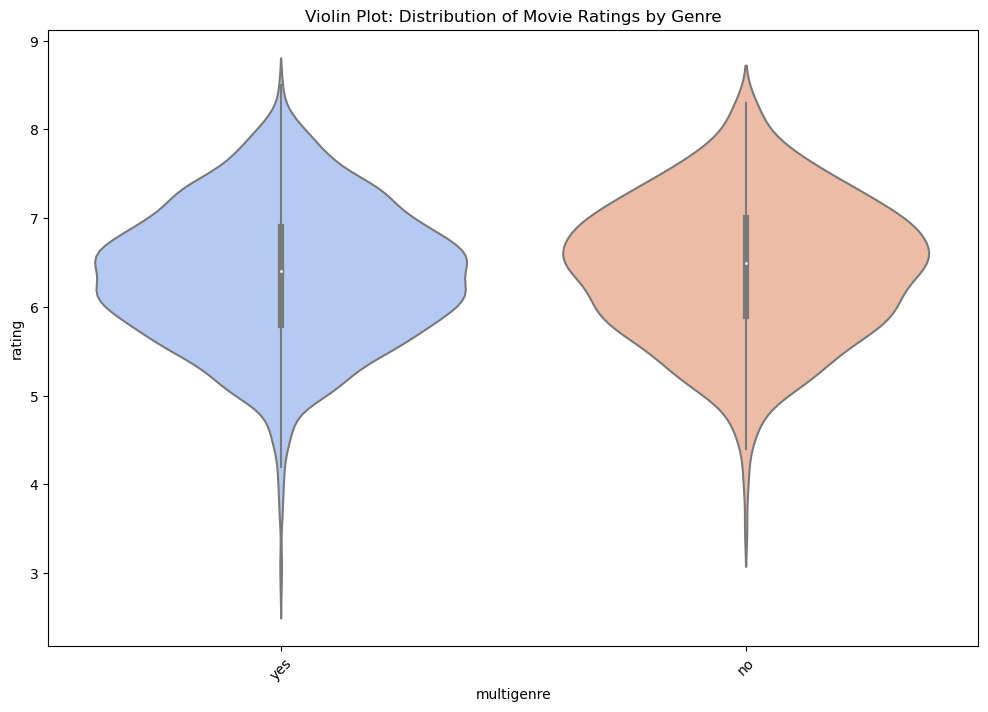

In [13]:
# Plot 1: Distribution of Movie Ratings by Genre (Violin Plot)
# Split the multi-genre column into separate rows for each genre
merged_data_expanded = merged_data.dropna(subset=['multigenre'])  # Drop rows where 'multigenre' is NaN
merged_data_expanded['multigenre'] = merged_data_expanded['multigenre'].str.split(', ')  # Split by comma and space
merged_data_expanded = merged_data_expanded.explode('multigenre')  # Explode into separate rows for each genre

# Create a violin plot for ratings by genre
plt.figure(figsize=(12, 8))  # Set plot size
sns.violinplot(x='multigenre', y='rating', data=merged_data_expanded, palette='coolwarm')  # Create violin plot
plt.title('Violin Plot: Distribution of Movie Ratings by Genre')  # Set title
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.show()  # Show the plot

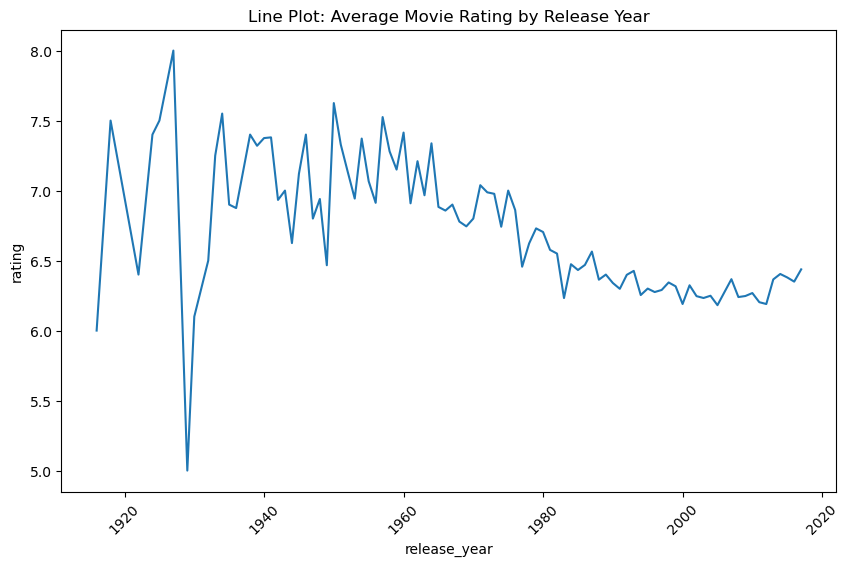

In [14]:
# Plot 2: Average Rating by Release Year (Line Plot)
merged_data['release_year'] = pd.to_datetime(merged_data['release_date']).dt.year  # Extract year from release_date
average_rating = merged_data.groupby('release_year')['rating'].mean().reset_index()  # Group by year, calculate average rating
plt.figure(figsize=(10, 6))  # Set figure size for the plot
sns.lineplot(x='release_year', y='rating', data=average_rating)  # Create a line plot for average rating by year
plt.title('Line Plot: Average Movie Rating by Release Year')  # Set title for the plot
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()  # Display the plot

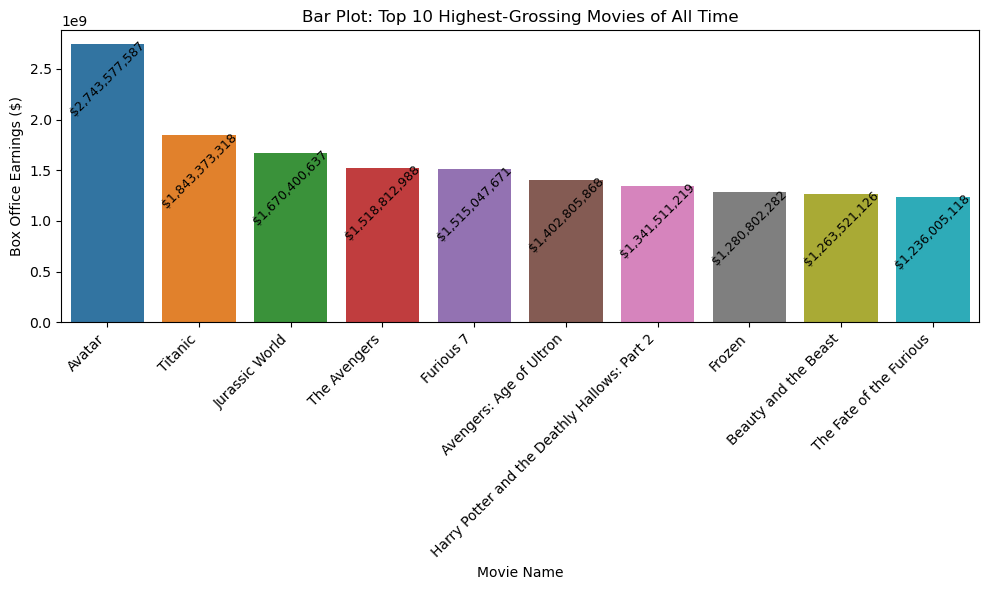

In [15]:
# Plot 3: Top 10 Highest-Grossing Movies of All Time (Bar Plot)
merged_data['box_office'] = merged_data['box_office'].replace({'\$': '', ',': ''}, regex=True).astype(float)  # Clean box office data
top_movies = merged_data.nlargest(10, 'box_office')  # Get top 10 highest-grossing movies

# Create the bar plot
plt.figure(figsize=(10, 6))  # Set plot size
ax = sns.barplot(x='movie_name', y='box_office', data=top_movies)  # Create bar plot

# Add slanted data labels to each bar
for i in range(len(top_movies)):
    ax.text(
        i,  # x-coordinate: bar position (index)
        top_movies['box_office'].iloc[i] + 0.05e9,  # y-coordinate: box office value, with slight offset
        f'${top_movies["box_office"].iloc[i]:,.0f}',  # Label text: box office (formatted with commas and $)
        ha='center',  # Horizontal alignment (centered on the bar)
        va='top',  # Vertical alignment (places label within the bar)
        fontsize=9,  # Font size for labels
        color='black',  # Label color
        rotation=45  # Slant labels at a 45-degree angle
    )

# Set plot title and labels
plt.title('Bar Plot: Top 10 Highest-Grossing Movies of All Time')
plt.xlabel('Movie Name')
plt.ylabel('Box Office Earnings ($)')

# Rotate x-axis labels for readability and fix alignment
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels and align them to the right
plt.tight_layout()  # Ensure the labels don't get cut off
plt.show()  # Show the plot


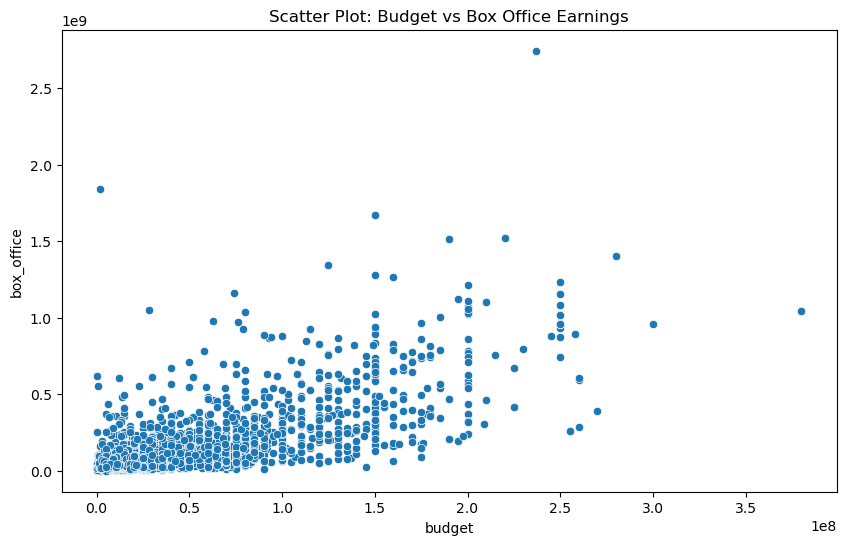

In [16]:
# Plot 4: Budget vs Box Office Earnings (Scatter Plot)
merged_data['budget'] = merged_data['budget'].replace({'\$': '', ',': ''}, regex=True).astype(float)  # Clean budget data

plt.figure(figsize=(10, 6))  # Set plot size
sns.scatterplot(x='budget', y='box_office', data=merged_data)  # Create scatter plot
plt.title('Scatter Plot: Budget vs Box Office Earnings')  # Set title
plt.show()  # Show the plot

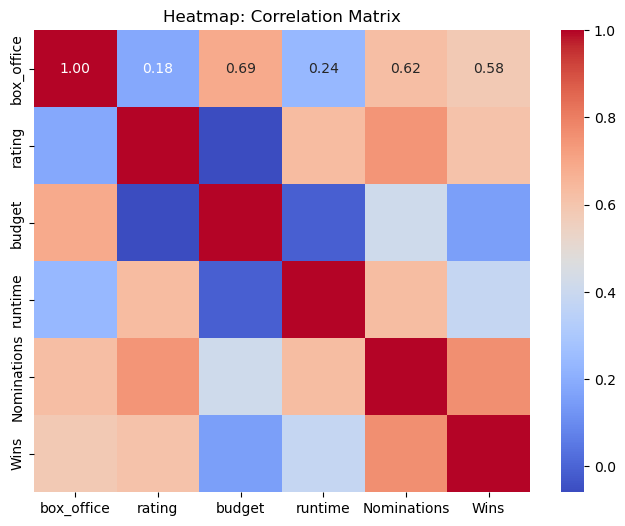

In [17]:
# Plot 5: Correlation Matrix (Heatmap) for Numerical Data
corr = merged_data[['box_office', 'rating', 'budget', 'runtime', 'Nominations', 'Wins']].corr()  # Calculate correlations
plt.figure(figsize=(8, 6))  # Set plot size
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)  # Create heatmap
plt.title('Heatmap: Correlation Matrix')  # Set title
plt.show()  # Show the plot

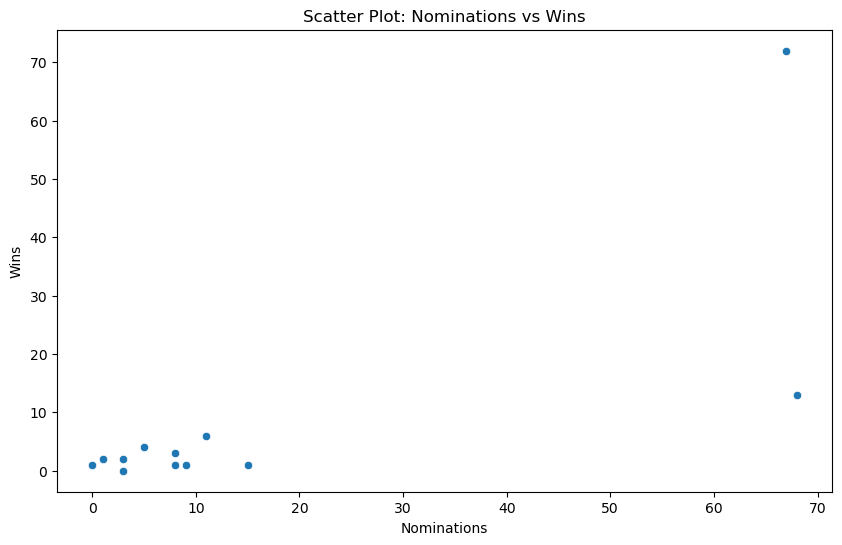

In [18]:

# Plot 6: Number of Nominations vs Wins (Scatter Plot)
plt.figure(figsize=(10, 6))  # Set plot size
sns.scatterplot(x='Nominations', y='Wins', data=merged_data)  # Create scatter plot
plt.title('Scatter Plot: Nominations vs Wins')  # Set title
plt.show()  # Show the plot


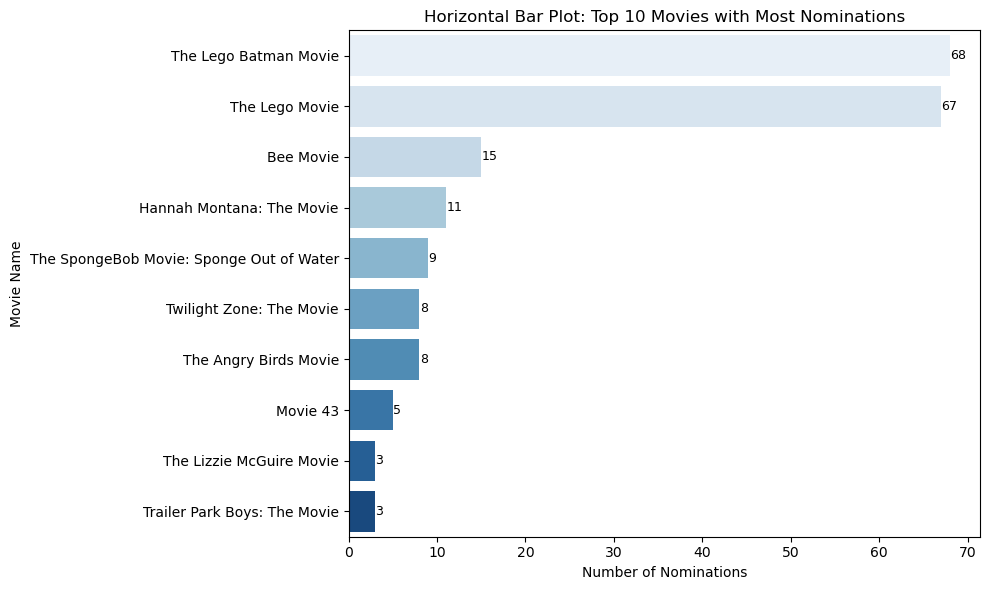

In [19]:
# Plot 7: Top 10 Movies with Most Nominations (Horizontal Bar Plot)

top_nominated_movies = merged_data.nlargest(10, 'Nominations')  # Get top 10 movies with most nominations

plt.figure(figsize=(10, 6))  # Set plot size
ax = sns.barplot(x='Nominations', y='movie_name', data=top_nominated_movies, palette='Blues')  # Horizontal bar plot

# Add slanted data labels to each bar
for i in range(len(top_nominated_movies)):
    ax.text(
        top_nominated_movies['Nominations'].iloc[i] + 0.05,  # x-coordinate: nomination value, with slight offset
        i,  # y-coordinate: bar position (index)
        f'{top_nominated_movies["Nominations"].iloc[i]:,.0f}',  # Label text: nominations (formatted with commas)
        ha='left',  # Horizontal alignment (centered on the bar)
        va='center',  # Vertical alignment
        fontsize=9,  # Font size for labels
        color='black'  # Label color
    )

# Set plot title and labels
plt.title('Horizontal Bar Plot: Top 10 Movies with Most Nominations')
plt.xlabel('Number of Nominations')
plt.ylabel('Movie Name')
plt.tight_layout()
plt.show()


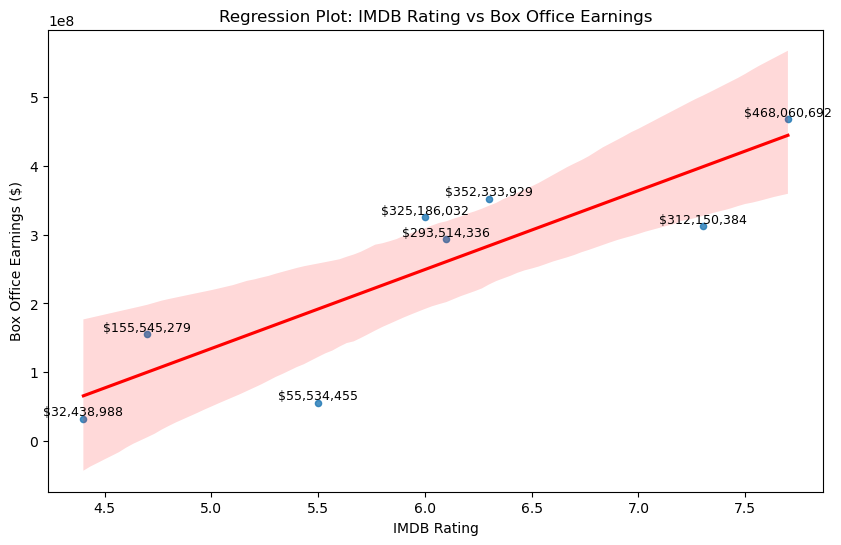

In [20]:
# Plot 8: IMDB Rating vs Box Office Earnings (Regression Plot)

# Convert 'imdb_rating' and 'box_office' to numeric, coercing errors to NaN (if any non-numeric values exist)
merged_data['imdb_rating'] = pd.to_numeric(merged_data['imdb_rating'], errors='coerce')
merged_data['box_office'] = pd.to_numeric(merged_data['box_office'], errors='coerce')

# Drop rows with NaN values in the 'imdb_rating' or 'box_office' columns
merged_data_cleaned = merged_data.dropna(subset=['imdb_rating', 'box_office'])

# Now, proceed with the regression plot
plt.figure(figsize=(10, 6))  # Set plot size
ax = sns.regplot(
    x='imdb_rating',  # X-axis: IMDB Rating
    y='box_office',  # Y-axis: Box Office Earnings
    data=merged_data_cleaned,  # Data source
    scatter_kws={'s': 20},  # Customize scatter plot marker size
    line_kws={'color': 'red'}  # Customize regression line color (red)
)

# Add slanted data labels to each point in the scatter plot
for i in range(len(merged_data_cleaned)):
    ax.text(
        merged_data_cleaned['imdb_rating'].iloc[i],  # X-coordinate: IMDB Rating
        merged_data_cleaned['box_office'].iloc[i],  # Y-coordinate: Box Office Earnings
        f'${merged_data_cleaned["box_office"].iloc[i]:,.0f}',  # Label text: Box Office (formatted with commas and $)
        ha='center',  # Horizontal alignment (centered on the point)
        va='bottom',  # Vertical alignment (places label above the point)
        fontsize=9,  # Font size for labels
        color='black'  # Label color
    )

# Set plot title and labels
plt.title('Regression Plot: IMDB Rating vs Box Office Earnings')
plt.xlabel('IMDB Rating')  # X-axis label
plt.ylabel('Box Office Earnings ($)')  # Y-axis label

# Show the plot
plt.show()  # Show the plot


### Ethical Implications of Data Wrangling on the Dataset:

The ethical implications of data wrangling in this project revolve around the integrity and fairness of the insights derived from the movie industry datasets. These datasets include financial figures, ratings, and other performance metrics that may influence public perception and industry decision-making. Ensuring accuracy during data cleaning (e.g., handling missing values, removing anomalies, or standardizing formats) is critical, as misrepresentation or bias in the cleaned data could lead to skewed analyses that unfairly benefit or harm certain films, studios, or genres. Additionally, data privacy concerns may arise if sensitive information, such as proprietary financial data or API-sourced content, is used or shared without proper authorization. This emphasizes the importance of transparency in data transformations and adherence to ethical and legal standards when handling third-party data.

###  **Summary of Changes**

**1. Dataset Integration:**  
Three datasets were merged into a comprehensive dataset:  
- `file_dataset`: Provided movie metadata, including titles, genres, and budget information.  
- `website_dataset`: Included box office earnings and other performance metrics.  
- `api_dataset`: Contained movie details such as runtime, nominations, wins, and IMDB ratings.  

The datasets were linked primarily using the `original_title` column.


**2. Data Cleaning:**  
- **Monetary Columns:** 
  - Columns like `box_office` and `budget` had dollar signs (`$`) and commas removed. 
  - Values were converted to numeric format for analysis.
- **Missing Data Handling:**
  - Missing values in critical columns (`IMDB Rating`, `box_office`, etc.) were handled either by dropping incomplete rows or replacing missing values where appropriate.
- **Genre Handling:**  
  - The `multi-genre` column was split into individual genres to facilitate genre-specific analysis.  
- **Date Parsing:**  
  - The `release_date` column was parsed to extract the release year, enabling temporal analyses.  


**3. Merging and SQL Query Construction:**  
A custom SQL query was constructed to retrieve key fields from all three datasets. The following fields were included in the merged dataset:
- **From `file_dataset`:**  
  - `id`, `original_title`, `genres`, `release_date`, `vote_average` (renamed as `rating`), `budget`, `multigenre`, `multilanguage`, `multicompany`, `multicountry`.  
- **From `website_dataset`:**  
  - `Worldwide` (renamed as `box_office`).  
- **From `api_dataset`:**  
  - `IMDB Rating`, `Country`, `Year`, `Runtime(in mins)` (renamed as `runtime`), `Nominations`, `Wins`.  


**4. Transformation Outputs:**  
- The cleaned and merged dataset was saved as `merged_movies_data.csv` for further analysis and visualization.  
- Key numeric columns were validated and converted to float for compatibility with data visualization libraries like Matplotlib and Seaborn.


**5. Error Handling:**  
The code includes error handling to ensure smooth execution even if issues arise during database creation, data merging, or transformations.  

This comprehensive workflow ensures the data is clean, consistent, and ready for insightful analysis.


### **Legal and Regulatory Guidelines**: 
- In working with public datasets, it is important to consider legal and regulatory frameworks like copyright laws, intellectual property rights, and privacy laws. While the data in this project does not contain sensitive personal information, any future projects that involve user data would require adherence to privacy laws such as GDPR or CCPA. Additionally, the usage of copyrighted movie titles or proprietary box office data must be done within the bounds of fair use or with proper licensing.

### **Risks Created by Transformations**: 
- Data cleaning processes introduce risks like the loss of important information due to dropped or coerced `NaN` values. Assumptions made during cleaning, such as uniform formats for box office data or multi-genre listings, could lead to misinterpretations if the data is inconsistent. For instance, incorrect handling of non-standardized formats could result in data errors. Similarly, overfitting in visualizations, like focusing on the top 10 highest-grossing movies, might create biased insights that don't reflect the full scope of the data.

### **Assumptions in Cleaning/Transforming the Data**: 
- The data was cleaned under several assumptions: multi-genre entries are consistently comma-separated, missing values represent incomplete data, and numeric values in `IMDB Rating` and `box_office` can be coerced to numbers. While these assumptions are reasonable, they might not always hold true across different datasets, which could affect the results.

### **Data Sourcing and Verification**: 
- The data was assumed to be sourced from reputable public databases like IMDB, BoxOfficeMojo, and The Movie Database (TMDb). However, data credibility should always be verified by cross-checking key information such as movie titles, ratings, and earnings with authoritative sources to ensure its accuracy and reliability.

### **Ethical Data Acquisition**: 
- The data appears to have been sourced ethically from publicly available databases, which reduces concerns about privacy violations. No personal or sensitive data was involved, but if user data were used, ensuring proper consent and transparency would be essential.

### **Mitigating Ethical Implications**: 
- To mitigate ethical risks, transparency should be maintained regarding data sources, and cross-verification with credible sources should be done regularly. Data cleaning assumptions should be carefully documented, and any potential biases in the dataset should be addressed to ensure fairness in the analysis. Additionally, proper licensing must be in place if proprietary data is used.

In conclusion, while the project adhered to ethical standards in terms of data sourcing and transformation, it is crucial to continuously monitor for potential risks related to data integrity, privacy, and bias. Ethical practices like transparency, cross-checking, and licensing will ensure the project’s credibility and reliability.censing will ensure the project’s credibility and reliability.y and reliability.